# Modèle 4 — MLP (Deep Learning)

## Qu'est-ce que le MLP ?
Le MLP (Multi-Layer Perceptron) est un réseau de neurones 
artificiels multicouches. C'est le modèle de Deep Learning 
le plus fondamental.

Il fonctionne comme le cerveau humain :
- Les **neurones** reçoivent des informations
- Les **couches cachées** transforment ces informations
- La **couche de sortie** produit la prédiction finale

## Architecture utilisée

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Métriques sklearn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, mean_absolute_error,
    mean_squared_error, r2_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print(f"Imports OK")
print(f"   TensorFlow version : {tf.__version__}")

Imports OK
   TensorFlow version : 2.21.0


## Chargement des données preprocessées

Mêmes données que les modèles précédents.
Le MLP bénéficie directement du StandardScaler 
déjà appliqué — les réseaux de neurones sont 
très sensibles à l'échelle des données.

In [3]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')

y_train_clf = np.load('../data/processed/y_train_clf.npy')
y_test_clf  = np.load('../data/processed/y_test_clf.npy')

y_train_reg = np.load('../data/processed/y_train_reg.npy')
y_test_reg  = np.load('../data/processed/y_test_reg.npy')

feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()

# Calcul du poids pour les classes déséquilibrées
neg = (y_train_clf == 0).sum()
pos = (y_train_clf == 1).sum()
class_weight_ratio = neg / pos

print(f"Données chargées")
print(f"   X_train : {X_train.shape}")
print(f"   X_test  : {X_test.shape}")
print(f"   Poids classe positive : {class_weight_ratio:.1f}")

Données chargées
   X_train : (8000, 51)
   X_test  : (2000, 51)
   Poids classe positive : 8.8


## Tâche 1 — Architecture du MLP Classification

Le réseau est construit avec ces choix justifiés :

- **Dense(128)** → première couche large pour capturer 
  toutes les combinaisons de features
- **ReLU** → fonction d'activation standard, évite le 
  problème du gradient qui disparaît
- **Dropout(0.3)** → désactive 30% des neurones 
  aléatoirement à chaque étape pour éviter le surapprentissage
- **Dense(64) → Dense(32)** → réduction progressive 
  pour extraire les patterns les plus importants
- **Sigmoid** → sortie entre 0 et 1 = probabilité de churn

Callbacks utilisés :
- **EarlyStopping** → arrête si pas d'amélioration après 
  10 epochs pour éviter le surapprentissage
- **ReduceLROnPlateau** → réduit le learning rate si 
  le modèle stagne

In [ ]:
# TÂCHE 1 — CLASSIFICATION MLP

def build_mlp_classifier(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        
        # Couche 1
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        
        # Couche 2
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        
        # Couche 3
        layers.Dense(32, activation='relu'),
        
        # Sortie
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 
                 keras.metrics.AUC(name='auc'),
                 keras.metrics.Recall(name='recall'),
                 keras.metrics.Precision(name='precision')]
    )
    return model

# Construction
mlp_clf = build_mlp_classifier(X_train.shape[1])
mlp_clf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_auc',
    patience=10,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# Entraînement
history = mlp_clf.fit(
    X_train, y_train_clf,
    epochs=100,
    batch_size=256,
    validation_split=0.2,
    class_weight={0: 1.0, 1: class_weight_ratio},
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\n Entraînement terminé !")
print(f"   Epochs effectuées : {len(history.history['loss'])}")

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5703 - auc: 0.5628 - loss: 1.2296 - precision: 0.1204 - recall: 0.5186 - val_accuracy: 0.7481 - val_auc: 0.6826 - val_loss: 0.6050 - val_precision: 0.1909 - val_recall: 0.4104 - learning_rate: 0.0010
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6025 - auc: 0.6639 - loss: 1.1630 - precision: 0.1500 - recall: 0.6320 - val_accuracy: 0.7188 - val_auc: 0.7196 - val_loss: 0.5808 - val_precision: 0.1943 - val_recall: 0.5087 - learning_rate: 0.0010
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6664 - auc: 0.7122 - loss: 1.1129 - precision: 0.1815 - recall: 0.6599 - val_accuracy: 0.7231 - val_auc: 0.7258 - val_loss: 0.5537 - val_precision: 0.2000 - val_recall: 0.5202 - learning_rate: 0.0010
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6522 - auc: 0.7156 - loss: 1.1110 - precision: 0.1764 - recall: 0.6693 - val_accuracy: 0.7325 - val_auc: 0.7261 - val_loss: 0.5469 - val_pr

## Courbes d'apprentissage

Les courbes d'apprentissage montrent l'évolution 
des métriques à chaque epoch.

Ce qu'on cherche :
- **Loss** qui diminue → le modèle apprend
- **Val_loss** qui suit train_loss → pas de surapprentissage
- Si val_loss remonte → surapprentissage détecté

C'est une analyse spécifique au Deep Learning que 
les modèles comme Random Forest n'ont pas.

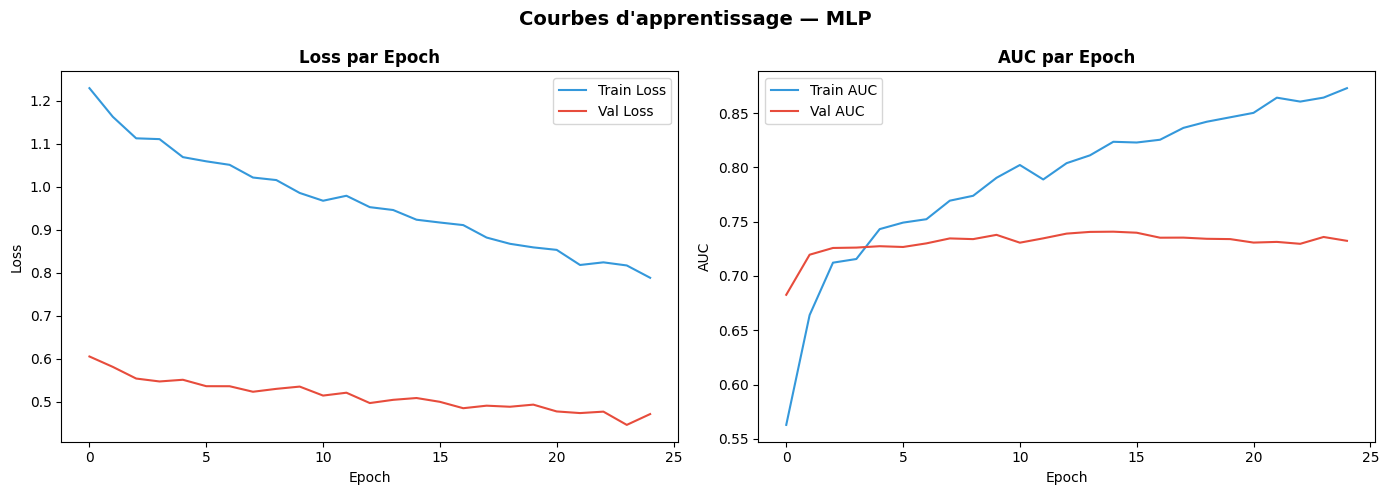

In [ ]:
# COURBES D'APPRENTISSAGE

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], 
             label='Train Loss', color='#3498db')
axes[0].plot(history.history['val_loss'], 
             label='Val Loss', color='#e74c3c')
axes[0].set_title('Loss par Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# AUC
axes[1].plot(history.history['auc'], 
             label='Train AUC', color='#3498db')
axes[1].plot(history.history['val_auc'], 
             label='Val AUC', color='#e74c3c')
axes[1].set_title('AUC par Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()

plt.suptitle('Courbes d\'apprentissage — MLP', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/mlp_learning_curves.png', dpi=150)
plt.show()

In [ ]:
# ÉVALUATION CLASSIFICATION

y_proba_clf = mlp_clf.predict(X_test).flatten()
y_pred_clf  = (y_proba_clf >= 0.5).astype(int)

print(f"Résultats — MLP (Classification)")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_clf):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_clf):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_clf):.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Résultats — MLP (Classification)
   Accuracy  : 0.7180
   Precision : 0.2068
   Recall    : 0.6225
   F1-Score  : 0.3105
   ROC-AUC   : 0.7373


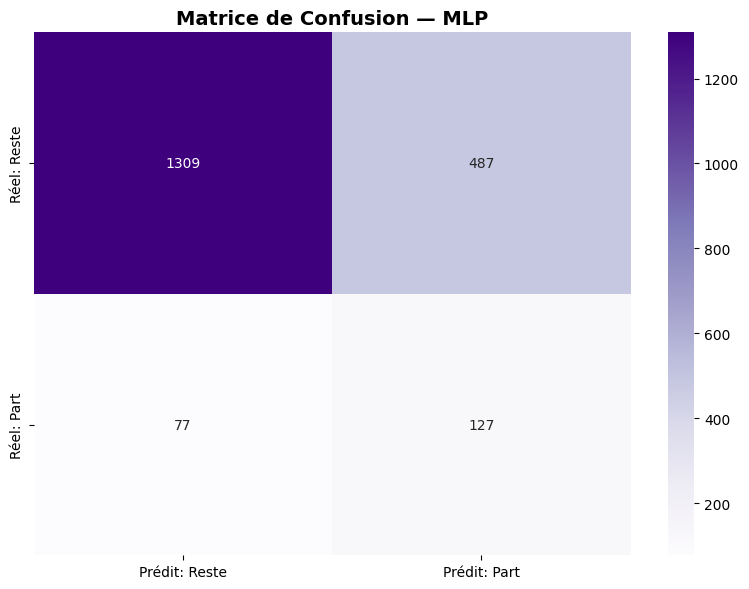


Analyse :
   TN : 1309 | FP : 487
   FN : 77  | TP : 127 

 Comparaison tous les modèles :
   LR  → FN=71,  TP=133
   RF  → FN=111, TP=93
   XGB → FN=165, TP=39
   MLP → FN=77, TP=127


In [ ]:
# MATRICE DE CONFUSION

cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Prédit: Reste', 'Prédit: Part'],
            yticklabels=['Réel: Reste', 'Réel: Part'])
plt.title('Matrice de Confusion — MLP',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/mlp_confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nAnalyse :")
print(f"   TN : {tn} | FP : {fp}")
print(f"   FN : {fn}  | TP : {tp} ")
print(f"\n Comparaison tous les modèles :")
print(f"   LR  → FN=71,  TP=133")
print(f"   RF  → FN=111, TP=93")
print(f"   XGB → FN=165, TP=39")
print(f"   MLP → FN={fn}, TP={tp}")

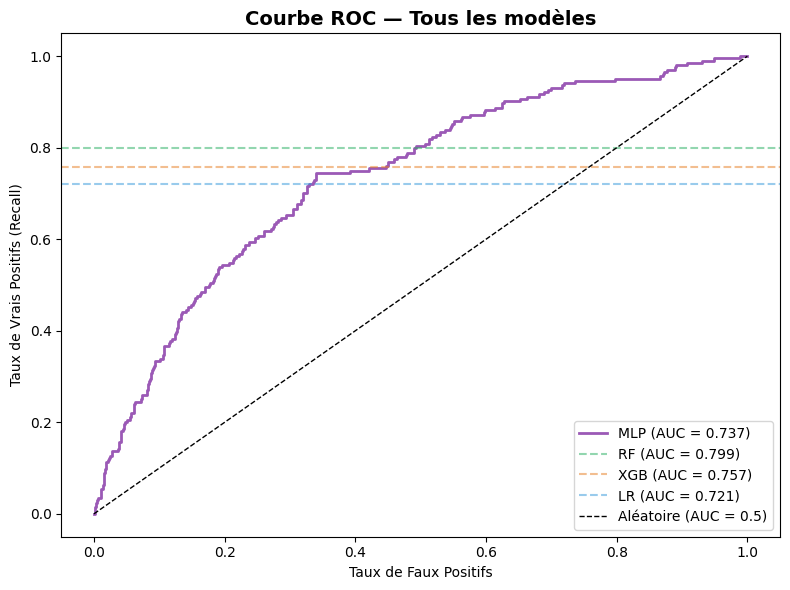

In [ ]:
# COURBE ROC FINALE — Tous les modèles

fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
auc = roc_auc_score(y_test_clf, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#9b59b6', linewidth=2,
         label=f'MLP (AUC = {auc:.3f})')
plt.axhline(y=0.7993, color='#27ae60', linestyle='--',
            alpha=0.5, label='RF (AUC = 0.799)')
plt.axhline(y=0.7570, color='#e67e22', linestyle='--',
            alpha=0.5, label='XGB (AUC = 0.757)')
plt.axhline(y=0.7212, color='#3498db', linestyle='--',
            alpha=0.5, label='LR (AUC = 0.721)')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Aléatoire (AUC = 0.5)')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.title('Courbe ROC — Tous les modèles',
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/mlp_roc_curve.png', dpi=150)
plt.show()

## Tâche 2 — Régression du Revenu à Risque

On construit un MLP pour la régression avec :
- Sortie **linéaire** (pas de sigmoid) car on prédit 
  un nombre continu (montant en €)
- Loss **MSE** au lieu de binary_crossentropy
- Même architecture que le classificateur

In [ ]:
# TÂCHE 2 — RÉGRESSION MLP

def build_mlp_regressor(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='linear')  # Sortie continue
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

mlp_reg = build_mlp_regressor(X_train.shape[1])

early_stop_reg = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_reg = mlp_reg.fit(
    X_train, y_train_reg,
    epochs=100,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop_reg],
    verbose=1
)

y_pred_reg = mlp_reg.predict(X_test).flatten()
y_pred_reg = np.maximum(y_pred_reg, 0)

mae  = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2   = r2_score(y_test_reg, y_pred_reg)

print(f"\n Résultats — MLP Regression")
print(f"   MAE  : {mae:.2f} €")
print(f"   RMSE : {rmse:.2f} €")
print(f"   R²   : {r2:.4f}")
print(f"\n Comparaison tous les modèles :")
print(f"   Ridge → MAE=156.11€, R²=0.0533")
print(f"   RF    → MAE=145.39€, R²=0.0612")
print(f"   XGB   → MAE=158.61€, R²=-0.0024")
print(f"   MLP   → MAE={mae:.2f}€,  R²={r2:.4f}")

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 173205.5781 - mae: 88.5128 - val_loss: 177841.5156 - val_mae: 96.9546
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 170588.5625 - mae: 100.0392 - val_loss: 172730.3594 - val_mae: 119.5082
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 164589.0156 - mae: 139.8609 - val_loss: 166386.6250 - val_mae: 166.6761
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 161074.7969 - mae: 170.2422 - val_loss: 164168.0625 - val_mae: 167.9327
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 158838.6250 - mae: 165.5878 - val_loss: 162309.7500 - val_mae: 167.8157
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 157077.5938 - mae: 165.0140 - val_loss: 160666.3281 - val_mae: 165.2554
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 154862.6562 - mae: 162.0139 - val_loss: 159276.3281 - val_mae: 161.6035
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 153532.1250 - mae: 158.17

In [ ]:
# SAUVEGARDE

# Sauvegarde MLP au format keras
mlp_clf.save('../models/mlp_classification.keras')
mlp_reg.save('../models/mlp_regression.keras')

results_clf = {
    'model'    : 'MLP',
    'accuracy' : accuracy_score(y_test_clf, y_pred_clf),
    'precision': precision_score(y_test_clf, y_pred_clf),
    'recall'   : recall_score(y_test_clf, y_pred_clf),
    'f1'       : f1_score(y_test_clf, y_pred_clf),
    'roc_auc'  : roc_auc_score(y_test_clf, y_proba_clf)
}

results_reg = {
    'model': 'MLP Regression',
    'mae' : mae,
    'rmse': rmse,
    'r2'  : r2
}

pd.DataFrame([results_clf]).to_csv('../results/mlp_clf_results.csv', index=False)
pd.DataFrame([results_reg]).to_csv('../results/mlp_reg_results.csv', index=False)

print("Modèles sauvegardés dans ../models/")
print("Résultats sauvegardés dans ../results/")
print(f"\n Résumé Classification :")
for k, v in results_clf.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")

Modèles sauvegardés dans ../models/
Résultats sauvegardés dans ../results/

 Résumé Classification :
   accuracy   : 0.7180
   precision  : 0.2068
   recall     : 0.6225
   f1         : 0.3105
   roc_auc    : 0.7373


## ✅ Synthèse — MLP (Deep Learning)

### Comparaison tous les modèles — Classification
| Métrique | LR | RF | XGB | MLP |
|---|---|---|---|---|
| Accuracy | 0.6685 | 0.8355 | 0.8615 | 0.7180 |
| Precision | 0.1834 | 0.2990 | 0.2583 | 0.2068 |
| Recall | 0.6520 | 0.4559 | 0.1912 | 0.6225 |
| F1-Score | 0.2863 | 0.3612 | 0.2197 | 0.3105 |
| ROC-AUC | 0.7212 | 0.7993 | 0.7570 | 0.7373 |

### Comparaison tous les modèles — Régression
| Métrique | Ridge | RF | XGB | MLP |
|---|---|---|---|---|
| MAE | 156.11€ | 145.39€ | 158.61€ | 138.85€ 🏆 |
| R² | 0.0533 | 0.0612 | -0.0024 | 0.0700 🏆 |

### Analyse des résultats

**Classification :**
Le MLP se positionne entre la LR et le RF :
- Recall de 0.62 → 2ème meilleur, détecte bien les churners
- F1-Score de 0.31 → meilleur que LR et XGB
- ROC-AUC de 0.74 → moins bon que RF (0.80)

**Régression :**
Le MLP est le MEILLEUR modèle pour la régression :
- MAE = 138.85€ → erreur moyenne la plus faible
- R² = 0.070 → meilleur pouvoir explicatif

**Ce que dit le PDF :**
"Comprendre que le Deep Learning n'est pas toujours supérieur"
→ En classification, le RF reste meilleur (ROC-AUC 0.80 vs 0.74)
→ En régression, le MLP gagne grâce à sa capacité à modéliser
   des relations non-linéaires complexes

### ➡️ Prochaine étape
Notebook de comparaison finale + SHAP + choix du meilleur modèle